# DEGs UpSet Plots

with [new reference genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)

# Phase 2 vs. Phase 2
using results from [deseq_p2.v.p2.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_p2.v.p2.ipynb) to look for DEGs that are shared/unique among the comparisons

## 0. load libraries

In [3]:
library(ggvenn)
library(tidyverse)
library(UpSetR)
library(patchwork)
library(rtracklayer)

## 1. read CSVs

In [4]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res',
    pattern = '\\.csv$',
    full.names = TRUE
    )

head(files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bb_cc.csv"
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_bb.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_cc.csv"
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_hc.csv"
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_wc.csv"
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bh_ch.csv"

In [5]:
names(files) <- tools::file_path_sans_ext(basename(files))
file_list <- lapply(files, read.csv)
names(file_list)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

In [6]:
head(file_list$bb_cc)

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1.973312e+03,-0.0332488130,0.10018698,0.82750435,0.4079513,0.8964045,0.9922542,2495.69160,2092.46282,⋯,2997.1598,989.093923,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527
2,LOC144621269,2.477696e+03,-0.0078655573,0.14736612,0.62056406,0.5348865,0.9348872,0.9804099,52.27077,1648.11743,⋯,14829.0276,3.288758,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403
3,LOC111120925,1.301645e+02,0.0085061583,0.15147791,-0.68050588,0.4961842,0.9239532,0.9787085,66.52643,23.22715,⋯,375.5976,0.000000,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321
4,Trnae-cuc-2,1.043799e-02,0.0001907784,0.32997597,-0.01429643,0.9885935,NA,0.9752358,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
5,Trnae-cuc-3,3.559860e-02,-0.0026528705,0.33519956,0.19674097,0.8440303,NA,0.9699419,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
6,LOC144621283,8.712697e+02,-0.0037226610,0.09670776,0.08951601,0.9286718,0.9959300,0.9930926,540.76486,870.51301,⋯,604.2222,1004.715522,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524


### pull out DEGs

In [7]:
deg_list <- lapply(file_list, function(df) {
  df %>% filter(abs(log2FoldChange) >= "1" & padj <= 0.05)
})

names(deg_list)
head(deg_list$bb_cc)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111102506,948.578114,1.113463,1.3782539,-3.721539,1.980124e-04,4.376733e-02,2.293073e-01,822.0766309,290.844253,⋯,112.13493,230.21305,275.54002,1135.877800,179.4902221,280.52256,796.800632,234.39864,285.80926,204.172325
2,LOC111117765,948.580792,1.019382,0.7028216,-4.035920,5.438871e-05,1.923475e-02,1.031210e-01,1030.2093271,726.100756,⋯,1376.10241,948.80664,354.08763,785.360948,624.4763979,619.93344,1457.901593,607.65903,376.35189,546.966914
3,LOC111104782,61.439122,1.360622,1.1165575,-3.947402,7.900399e-05,2.436630e-02,8.045647e-02,73.1790758,105.027091,⋯,39.19279,32.06539,92.26227,8.127927,183.2296018,26.76742,59.151139,36.65950,33.81713,8.596729
4,LOC144619911,263.266792,-3.777067,3.9685711,3.967465,7.264103e-05,2.349671e-02,1.289212e-01,0.0000000,20.197518,⋯,0.00000,2431.21424,1034.83357,1.015991,0.9348449,0.00000,2.319652,5.55447,4.36350,0.000000
5,LOC111105268,370.537252,-1.988343,2.3808844,3.881096,1.039866e-04,2.795036e-02,1.789722e-01,0.9503776,1852.112359,⋯,17.41902,204.72518,351.59406,42.671617,365.5243586,94.22132,336.349612,1969.61509,644.70715,53.729559
6,LOC111102028,7.951088,21.008371,3.3828306,-6.378646,1.786602e-10,2.961740e-07,6.332811e-07,0.0000000,3.029628,⋯,59.87787,12.33284,0.00000,1.015991,0.0000000,0.00000,0.000000,0.00000,0.00000,4.298365


### import GFF file
using [`rtracklayer`](https://bioconductor.org/packages/3.22/bioc/html/rtracklayer.html)

In [8]:
gff.file <- import('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/genome/GCF_053477285.1_ASM5347728v1_genomic.gff') %>%
as.data.frame() %>%
select(description, gene, gene_biotype) %>%
na.omit()

head(gff.file)

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
2,protein O-mannosyl-transferase TMTC2-like,LOC144621260,protein_coding
28,uncharacterized LOC144621269,LOC144621269,protein_coding
63,mitochondrial amidoxime-reducing component 1-like,LOC111120925,protein_coding
79,transfer RNA glutamic acid (anticodon CUC),Trnae-cuc,tRNA
82,transfer RNA glutamic acid (anticodon CUC),Trnae-cuc,tRNA
85,transfer RNA glutamic acid (anticodon CUC),Trnae-cuc,tRNA


## 2. Exploratory Plots

### total DEGs
look at total number of DEGs and up- and down-regulated DEGs for each pairwise comparison

In [9]:
deg_summary <- data.frame(
  dataset = names(deg_list),
  total_genes = sapply(deg_list, nrow),
  upregulated = sapply(deg_list, function(df) sum(df$log2FoldChange > 0)),
  downregulated = sapply(deg_list, function(df) sum(df$log2FoldChange < 0))
)

deg_summary

,dataset,total_genes,upregulated,downregulated
,<chr>,<int>,<int>,<int>
bb_cc,bb_cc,107,70,37
bc_bb,bc_bb,245,37,208
bc_cc,bc_cc,176,38,138
bc_hc,bc_hc,185,53,132
bc_wc,bc_wc,242,47,195
bh_ch,bh_ch,382,136,246
bh_hh,bh_hh,286,132,154
bw_cw,bw_cw,165,51,114
bw_ww,bw_ww,155,45,110


the up and down regulated aren't really that helpful bc it's in relation to the pair, so the only ones that are truly up or down regulated in a way that makes sense easily are the comparisons with CC

In [10]:
# reorder the rows from most DEGs to lease
deg_summary$dataset <- forcats::fct_reorder(deg_summary$dataset, deg_summary$total_genes, .fun = sum)

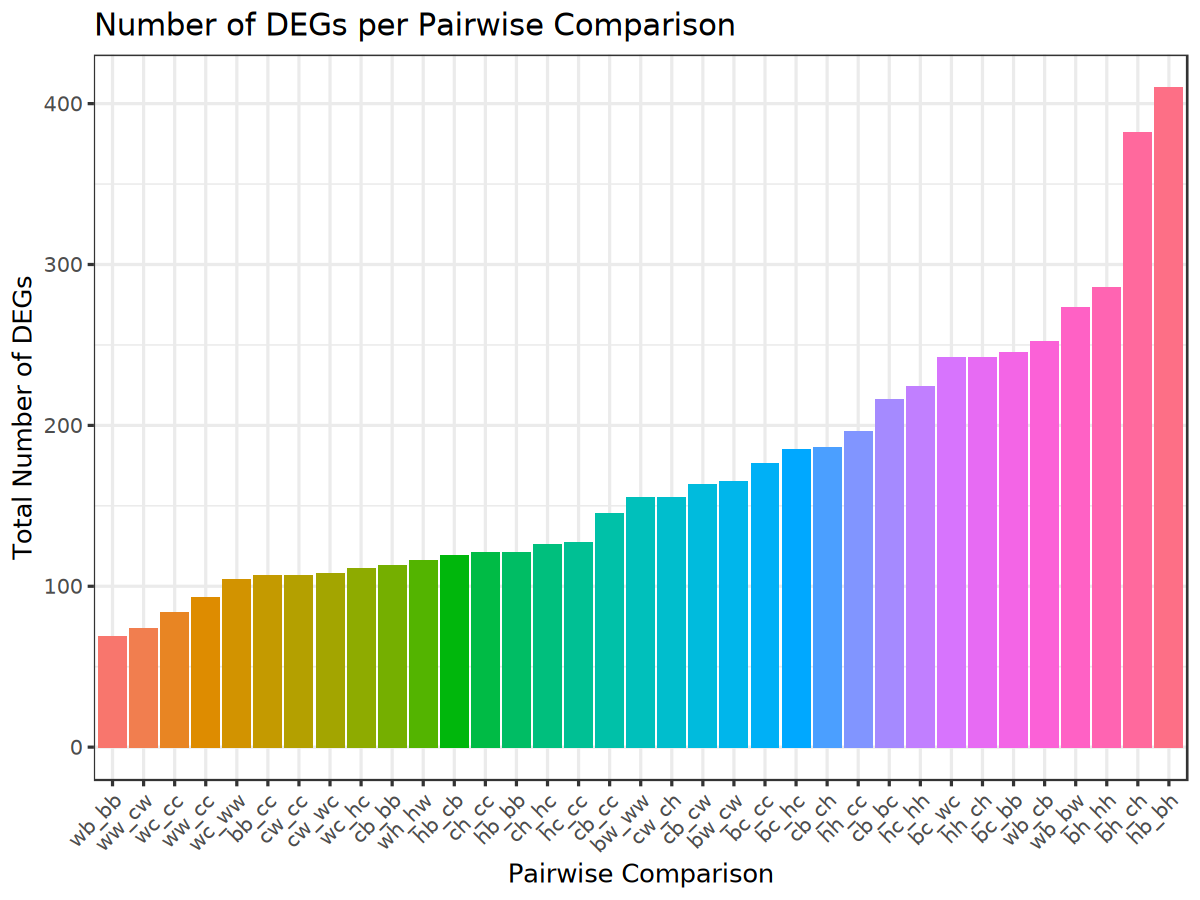

In [11]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

ggplot(deg_summary, aes(x = dataset, y = total_genes, fill = dataset)) +
geom_bar(stat = 'identity') +
guides(fill = 'none') +
theme_bw(base_size = 15) +
labs(title = 'Number of DEGs per Pairwise Comparison', 
    y = 'Total Number of DEGs',
    x = 'Pairwise Comparison') +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

the least amount of DEGs between a pair:
- **WB vs. BB**: maybe early exposure to warming helps prep for a later exposure to multiple stressors?
- **WW vs. CW**: same thing (also worth noting that the majority of the gene expression seems to be drive by the second exposure, so we're seeing a small carryover effect from the previous environment)

the most amount of DEGs between a pair
- **HB vs. BH**: each exhbited a single and multiple stressor exposure but at different times - emphasizes the importance of timing? or just that warming overpowers hypoxia differently depending on time of exposure?
- **BH vs. CH**: priming with multi stressor vs no stressor when the later stress is hypoxia alone - priming doesn't help here? or maybe multiple stressors early on is really detrimental/causes a lot of shifts?

### CC comparison DEGs

In [12]:
cc_deg <- deg_summary %>%
  filter(grepl("cc", dataset)) %>%
  pivot_longer(
    cols = c(upregulated, downregulated),
    names_to = "direction",
    values_to = "dir_degs"
  )

head(cc_deg)

dataset,total_genes,direction,dir_degs
<fct>,<int>,<chr>,<int>
bb_cc,107,upregulated,70
bb_cc,107,downregulated,37
bc_cc,176,upregulated,38
bc_cc,176,downregulated,138
cb_cc,145,upregulated,62
cb_cc,145,downregulated,83


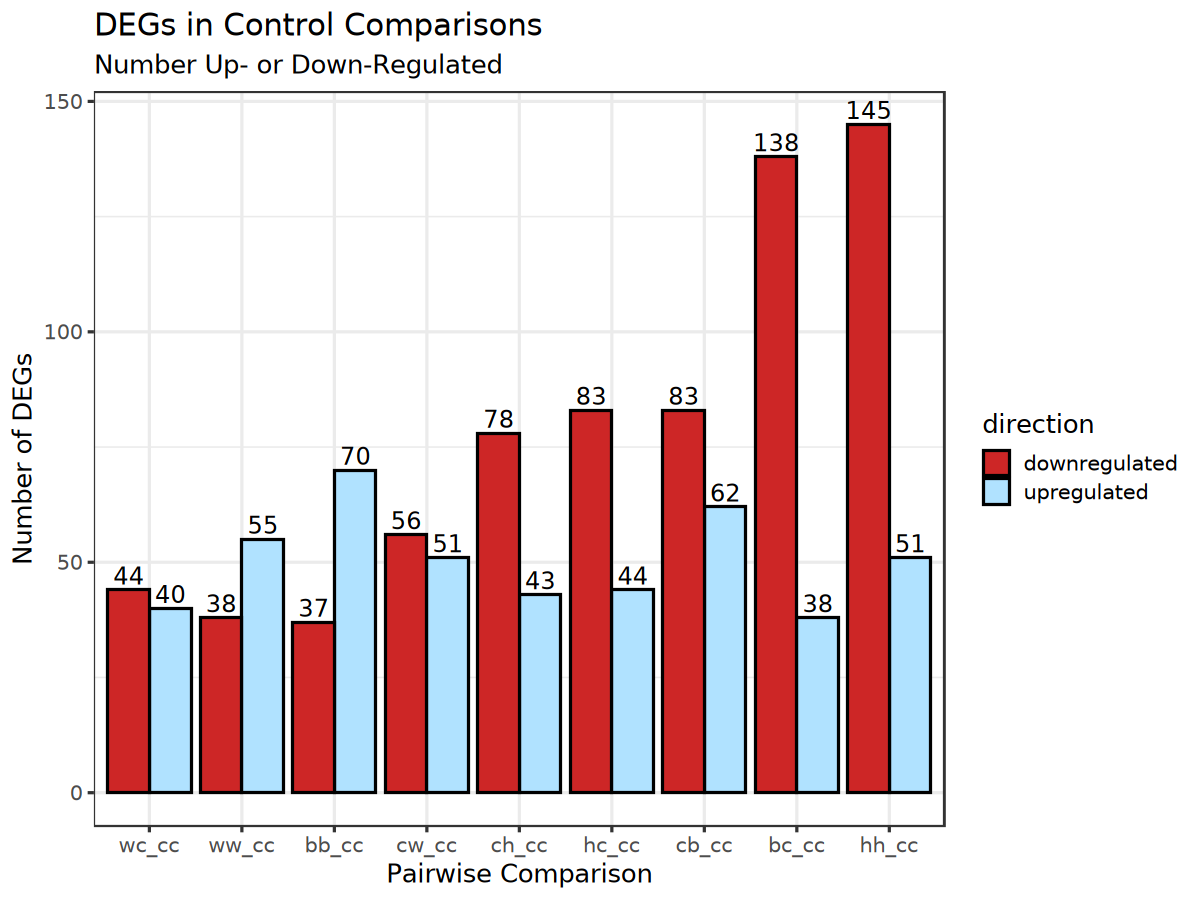

In [13]:
ggplot(cc_deg, aes(x = dataset, y = dir_degs, fill = direction)) +
geom_bar(stat = 'identity', position = 'dodge', col = 'black') +
  geom_text(
    aes(label = dir_degs),
    position = position_dodge(width = 0.9),
    vjust = -0.3,
    size = 5
  ) +
scale_fill_manual(values = c('firebrick3','lightskyblue1')) +
theme_bw(base_size = 15) +
labs(title = 'DEGs in Control Comparisons',
     subtitle = 'Number Up- or Down-Regulated',
     x = 'Pairwise Comparison',
     y = 'Number of DEGs')

**observations**:
- only two comparisons have more downregulated genes than up - WW and BB - so these have a dampenend response to double of the same stressor(s) ?
- interesting that the warm treatments tend to have a lower number of degs, despite most of my analysis saying that the second exposure to hypoxia and especially warming is influencing gene expression
- strong upregulated response to HH and BC (almost 60 more upregulated DEGs than any other comparison)
    - early life exposure to multiple stressors = sensitive window, really stressful with lasting response? 

In [14]:
cc_deg2 <- cc_deg %>%
separate(dataset,
           into = c("comp1", "comp2"),
           sep = "_",
           fill = "left",
          remove = FALSE) %>%
mutate(comp_group = case_when(
    substr(comp1, 1, 1) == 'c' ~ 'single late exposure',
    substr(comp1, 2, 2) == 'c' ~ 'single early exposure',
    TRUE ~ 'repeated exposure'))

head(cc_deg2)

dataset,comp1,comp2,total_genes,direction,dir_degs,comp_group
<fct>,<chr>,<chr>,<int>,<chr>,<int>,<chr>
bb_cc,bb,cc,107,upregulated,70,repeated exposure
bb_cc,bb,cc,107,downregulated,37,repeated exposure
bc_cc,bc,cc,176,upregulated,38,single early exposure
bc_cc,bc,cc,176,downregulated,138,single early exposure
cb_cc,cb,cc,145,upregulated,62,single late exposure
cb_cc,cb,cc,145,downregulated,83,single late exposure


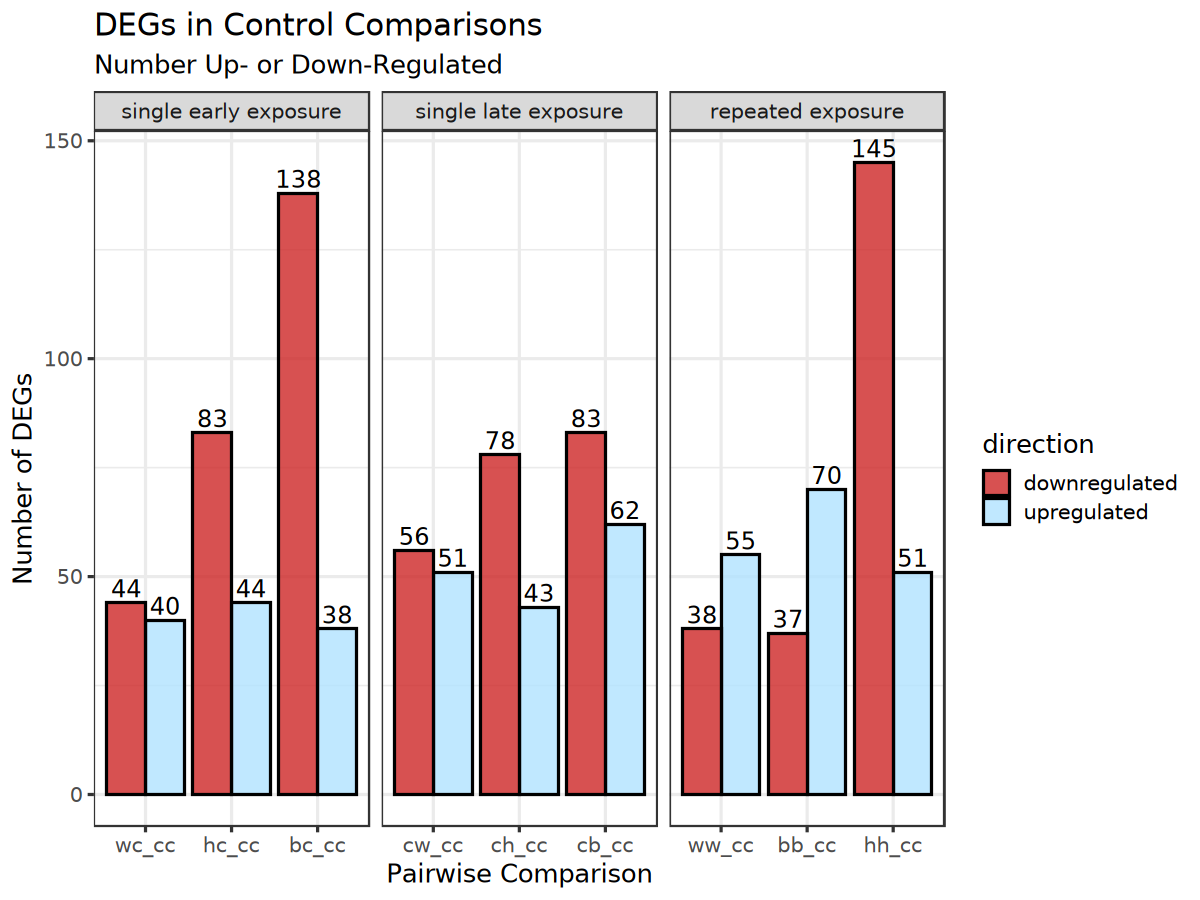

In [15]:
# set order of comparison group
cc_deg2$comp_group <- factor(
  cc_deg2$comp_group,
  levels = c(
    "single early exposure",
    "single late exposure",
    "repeated exposure"
  )
)

ggplot(cc_deg2, aes(x = dataset, y = dir_degs, fill = direction)) +
geom_bar(stat = 'identity', position = 'dodge', col = 'black', alpha = 0.8) +
  geom_text(
    aes(label = dir_degs),
    position = position_dodge(width = 0.9),
    vjust = -0.3,
    size = 5
  ) +
facet_wrap(~comp_group, scales = 'free_x') +
scale_fill_manual(values = c('firebrick3','lightskyblue1')) +
theme_bw(base_size = 15) +
labs(title = 'DEGs in Control Comparisons',
     subtitle = 'Number Up- or Down-Regulated',
     x = 'Pairwise Comparison',
     y = 'Number of DEGs')

it's interesting that most DEGs are downregulated (but you see this pattern switch in WW and BB, where the majority of the DEGs are upregulated)

## 3. UpSet plots *within* comparison groups

### 1. Effect of single exposure after period of recovery

In [16]:
# make list of dfs
comp1 = list(WC_v_CC = deg_list$wc_cc$Gene,
         HC_v_CC = deg_list$hc_cc$Gene,
         BC_v_CC = deg_list$bc_cc$Gene)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”


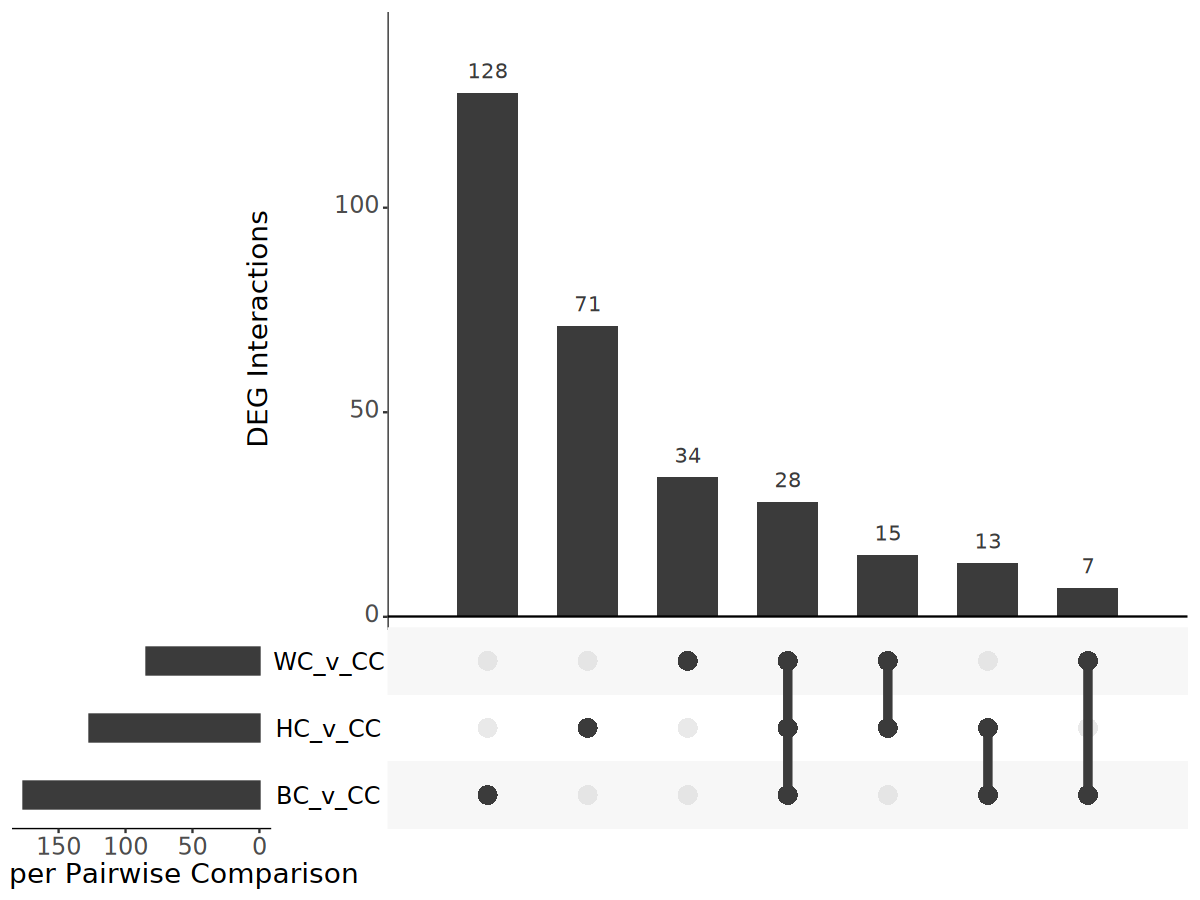

In [17]:
comp1.upset <- UpSetR::upset(
  fromList(comp1),
  nsets = 3,
  order.by = "freq",
  point.size = 5,
  line.size = 2,
  mainbar.y.label = "DEG Interactions",
  sets.x.label = "DEGs per Pairwise Comparison",
  text.scale = c(2, 2, 2, 2, 2, 2),
    empty.intersections = 'on'
)

comp1.upset

Majority of DEGs are not shared between these comparisons, but we do see that 28 genes are shared in all three - general stress response (to early stress) genes? 

same patterns remain as old genome, just reduced numbers

#### pull 28 shared genes 

In [18]:
# pull out the 28 shared genes across all 3 comparisons
shared_gene3 <- deg_list$wc_cc %>%
  inner_join(deg_list$hc_cc, by = "Gene") %>%
  inner_join(deg_list$bc_cc, by = "Gene") %>%
  pull(Gene) %>%
  unique()

length(shared_gene3)
shared_gene3

[1] 28

[1] "LOC111102028" "LOC111127247" "LOC144622232" "LOC144624450" "LOC144623104"
 [6] "LOC111116266" "LOC144624833" "LOC144624971" "LOC144625005" "LOC111116296"
[11] "LOC144626817" "LOC111099077" "LOC111136642" "LOC111132872" "LOC144627224"
[16] "LOC144619016" "LOC144619236" "LOC111128708" "LOC144619617" "LOC111130993"
[21] "LOC111118775" "LOC111119065" "LOC111118161" "LOC111114163" "LOC144621228"
[26] "LOC144621324" "LOC111114643" "LOC144621941"

In [19]:
gff.file[gff.file$gene %in% shared_gene3, ]

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
88655,uncharacterized LOC111102028,LOC111102028,lncRNA
172907,uncharacterized LOC111127247,LOC111127247,protein_coding
312586,uncharacterized LOC144622232,LOC144622232,protein_coding
330103,uncharacterized LOC144624450,LOC144624450,protein_coding
353948,uncharacterized LOC144623104,LOC144623104,protein_coding
393852,uncharacterized LOC111116266,LOC111116266,lncRNA
415518,uncharacterized LOC144624833,LOC144624833,lncRNA
524639,spore cortex-lytic enzyme-like,LOC144624971,protein_coding
543419,lectin BRA-3-like,LOC144625005,protein_coding


In [20]:
write.csv(gff.file[gff.file$gene %in% shared_gene3, ], '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deg_interest/earlyLife_sharedAll.csv', row.names = FALSE)

the same 3 genes keep popping up: SCLE, BRA-3, and MFAP-4 (based on below, I added this chunk of code after)

but we also see two new players:
- LOC111132872: tyrosinase-like protein 1
    - enables oxidoreductase activity
    - [Zhu et al, 2021](https://link.springer.com/article/10.1007/s10126-021-10063-2) - looks at tyrosinase protein in *C. gigas* - involved in melanin biosynthesis
- LOC111118161: sodium/hydrogen exchanger 9B2-like
    - enables antiporter activity
    - involved in proton transmembrane transport
    - important for pH regulation and calcification ([Ranesg et al, 2020](https://link.springer.com/article/10.1007/s00360-020-01303-3) in *C. gigas*)

### 2. Effect of single late exposure

In [21]:
# make list of dfs
comp2 = list(CW_v_CC = deg_list$cw_cc$Gene,
         CH_v_CC = deg_list$ch_cc$Gene,
         CB_v_CC = deg_list$cb_cc$Gene)

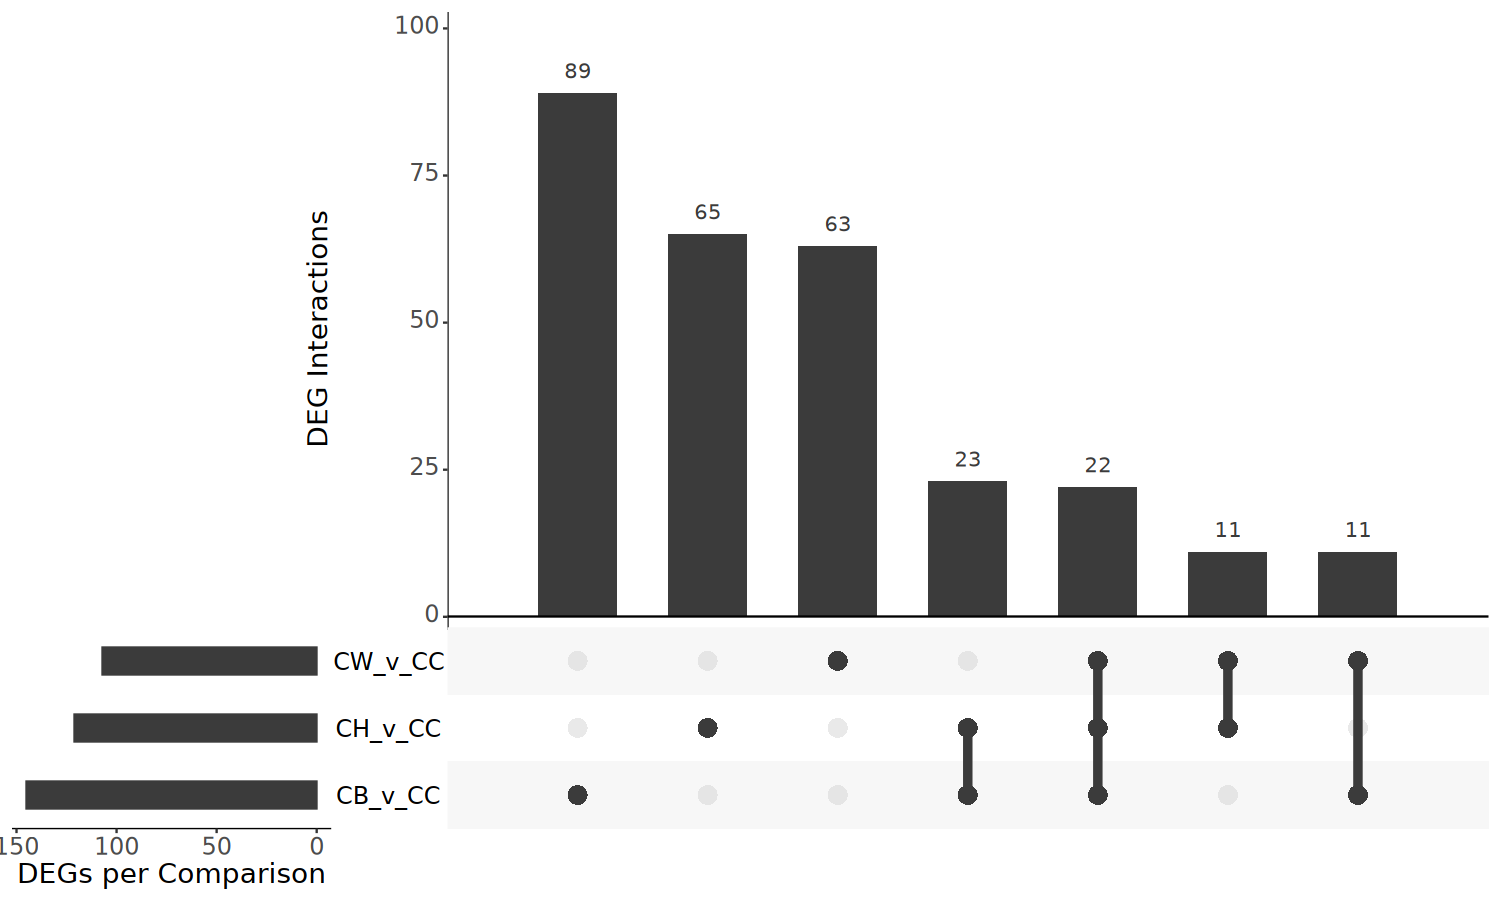

In [22]:
options(repr.plot.width=12.5, repr.plot.height=7.5)

comp2.upset <- UpSetR::upset(fromList(comp2), 
                             nsets = 6,
                             order.by='freq', 
                             point.size = 5, 
                             line.size = 2, 
                             mainbar.y.label = "DEG Interactions", 
                             sets.x.label = "DEGs per Comparison", 
                             text.scale = c(2, 2, 2, 2, 2, 2),
                             empty.intersections = 'on'
                            )

comp2.upset

The majority of DEGs are unique to that comparison - overall, there is a reduction in the number of DEGs but roughly the same pattern remains

- 22 are shared between all later stressors - general to late stress (doesn't matter if it's a single or multiple stressors)
- 11 shared between single late stressors
- 23 shared between late hypoxia
- 11 shared between late warming

In [23]:
# pull out the 22 shared genes across all 3 comparisons
shared_geneLate <- deg_list$cw_cc %>%
  inner_join(deg_list$ch_cc, by = "Gene") %>%
  inner_join(deg_list$cb_cc, by = "Gene") %>%
  pull(Gene) %>%
  unique()

length(shared_geneLate)
shared_geneLate

gff.file[gff.file$gene %in% shared_geneLate, ]

[1] 22

[1] "LOC111102028" "LOC111127247" "LOC144624450" "LOC144623813" "LOC144623104"
 [6] "LOC111099988" "LOC111116266" "LOC144624833" "LOC144624971" "LOC111136642"
[11] "LOC111100026" "LOC111110618" "LOC111108826" "LOC144619223" "LOC144619016"
[16] "LOC111138244" "LOC111114254" "LOC111114163" "LOC144621228" "LOC144621324"
[21] "LOC144621252" "LOC144621941"

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
88655,uncharacterized LOC111102028,LOC111102028,lncRNA
172907,uncharacterized LOC111127247,LOC111127247,protein_coding
330103,uncharacterized LOC144624450,LOC144624450,protein_coding
338170,uncharacterized LOC144623813,LOC144623813,protein_coding
353948,uncharacterized LOC144623104,LOC144623104,protein_coding
368716,uncharacterized LOC111099988,LOC111099988,protein_coding
393852,uncharacterized LOC111116266,LOC111116266,lncRNA
415518,uncharacterized LOC144624833,LOC144624833,lncRNA
524639,spore cortex-lytic enzyme-like,LOC144624971,protein_coding


In [24]:
write.csv(gff.file[gff.file$gene %in% shared_geneLate, ], '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deg_interest/laterLife_sharedAll.csv', row.names = FALSE)

### Comparison 1 and 2 together

In [25]:
# make list of dfs
comp1_2 = list(WC_v_CC = deg_list$wc_cc$Gene,
         HC_v_CC = deg_list$hc_cc$Gene,
         BC_v_CC = deg_list$bc_cc$Gene,
             CW_v_CC = deg_list$cw_cc$Gene,
         CH_v_CC = deg_list$ch_cc$Gene,
         CB_v_CC = deg_list$cb_cc$Gene)

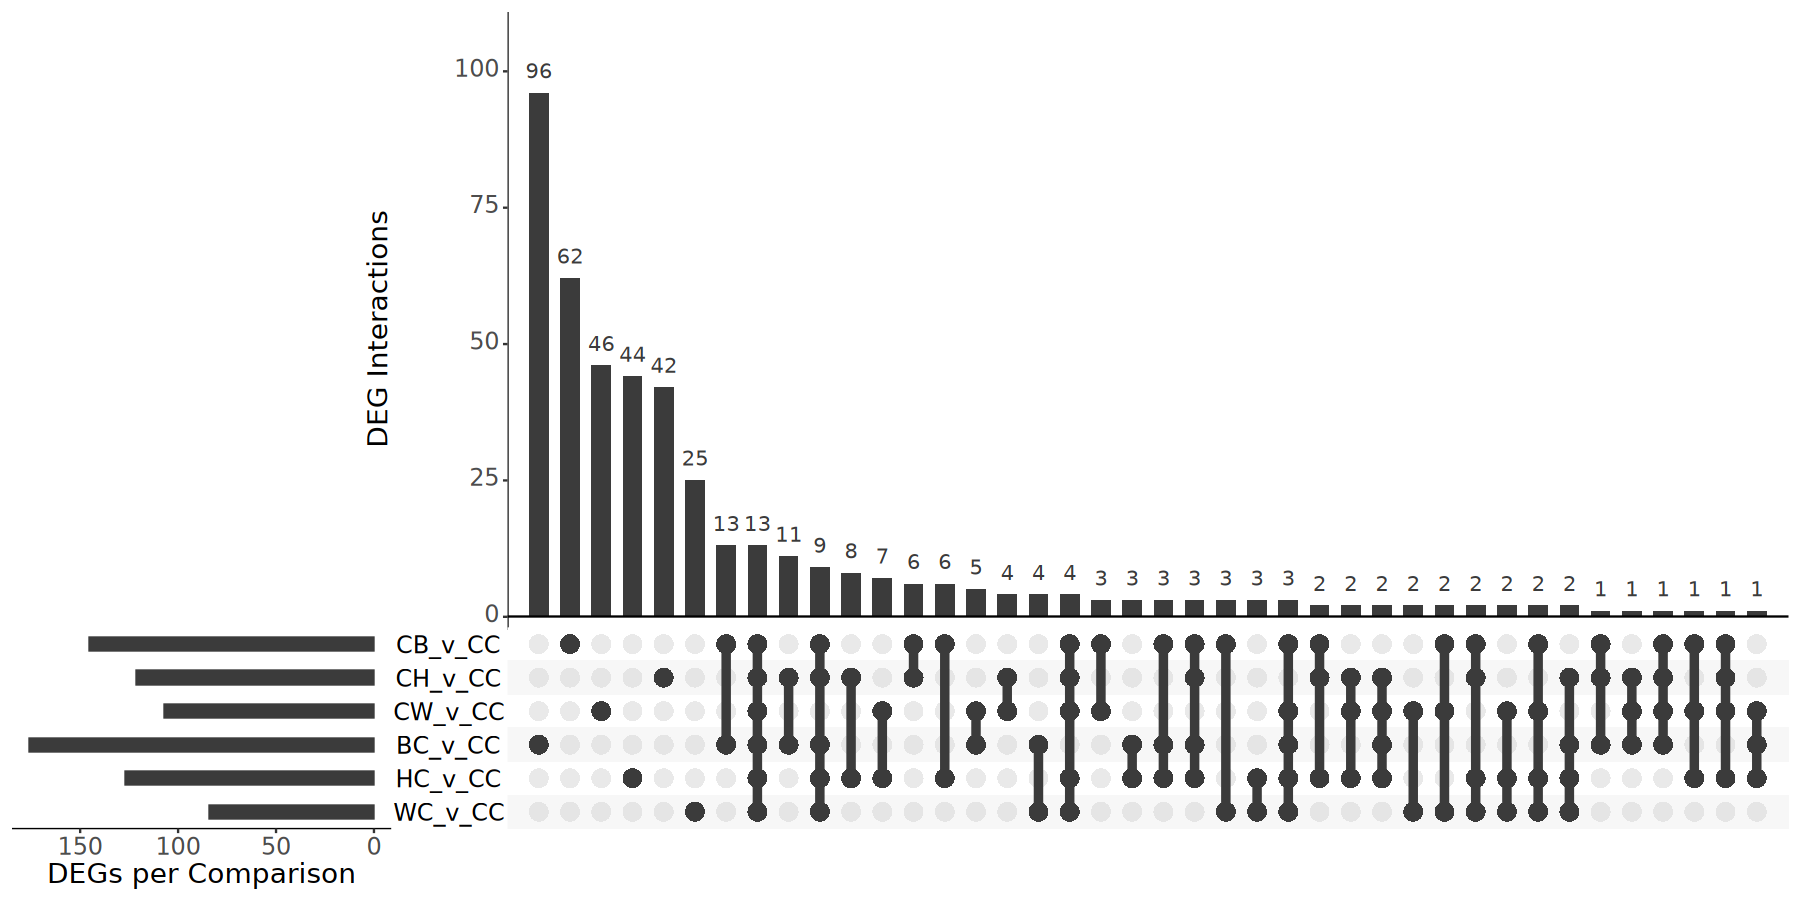

In [26]:
options(repr.plot.width=15, repr.plot.height=7.5)

comp1_2.upset <- UpSetR::upset(fromList(comp1_2), nsets = 6,, order.by='freq', point.size = 5, line.size = 2, keep.order=TRUE,
                       sets = c('WC_v_CC',
                                'HC_v_CC',
                                'BC_v_CC',
                                'CW_v_CC',
                                'CH_v_CC',
                                'CB_v_CC'),
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

comp1_2.upset

- the majority of DEGs are unique to that comparison
- 13 DEGs are shared among all the comparisons, so are a response to experiencing any stress only once (regardless of single/multiple stressors or timing)
- 13 DEGs shared in CB vs. CC and BC vs. CC, so response to experiencing both stressors simultaneously but only once (so doesn't matter the timing)
- most DEGs in a comparison: any interaction with both > any interaction with hypoxia > any interaction with warming

#### pull 13 genes shared in all single exposure stress

In [27]:
# pull out the 22 shared genes across all 3 comparisons
shared_gene1 <- deg_list$cb_cc %>%
  inner_join(deg_list$ch_cc, by = "Gene") %>%
  inner_join(deg_list$cw_cc, by = "Gene") %>%
inner_join(deg_list$bc_cc, by = "Gene") %>%
inner_join(deg_list$hc_cc, by = "Gene") %>%
inner_join(deg_list$wc_cc, by = "Gene") %>%
  pull(Gene) %>%
  unique()

length(shared_gene1)
shared_gene1

[1] 13

[1] "LOC111102028" "LOC111127247" "LOC144624450" "LOC144623104" "LOC111116266"
 [6] "LOC144624833" "LOC144624971" "LOC111136642" "LOC144619016" "LOC111114163"
[11] "LOC144621228" "LOC144621324" "LOC144621941"

In [28]:
gff.file[gff.file$gene %in% shared_gene1, ]

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
88655,uncharacterized LOC111102028,LOC111102028,lncRNA
172907,uncharacterized LOC111127247,LOC111127247,protein_coding
330103,uncharacterized LOC144624450,LOC144624450,protein_coding
353948,uncharacterized LOC144623104,LOC144623104,protein_coding
393852,uncharacterized LOC111116266,LOC111116266,lncRNA
415518,uncharacterized LOC144624833,LOC144624833,lncRNA
524639,spore cortex-lytic enzyme-like,LOC144624971,protein_coding
704434,uncharacterized LOC111136642,LOC111136642,protein_coding
868514,uncharacterized LOC144619016,LOC144619016,protein_coding


all uncharacterized except for **LOC144624971** which is spore cortex-lytic enzyme (enables hydrolase activity)

### 3. Effect of timing of initial stress exposure

I don't think it makes sense to look at the overlap for this comparison - skipping

### 4. No stress vs. most stress

In [29]:
# make list of dfs
comp4 = list(WW_v_CC = deg_list$ww_cc$Gene,
         HH_v_CC = deg_list$hh_cc$Gene,
         BB_v_CC = deg_list$bb_cc$Gene)

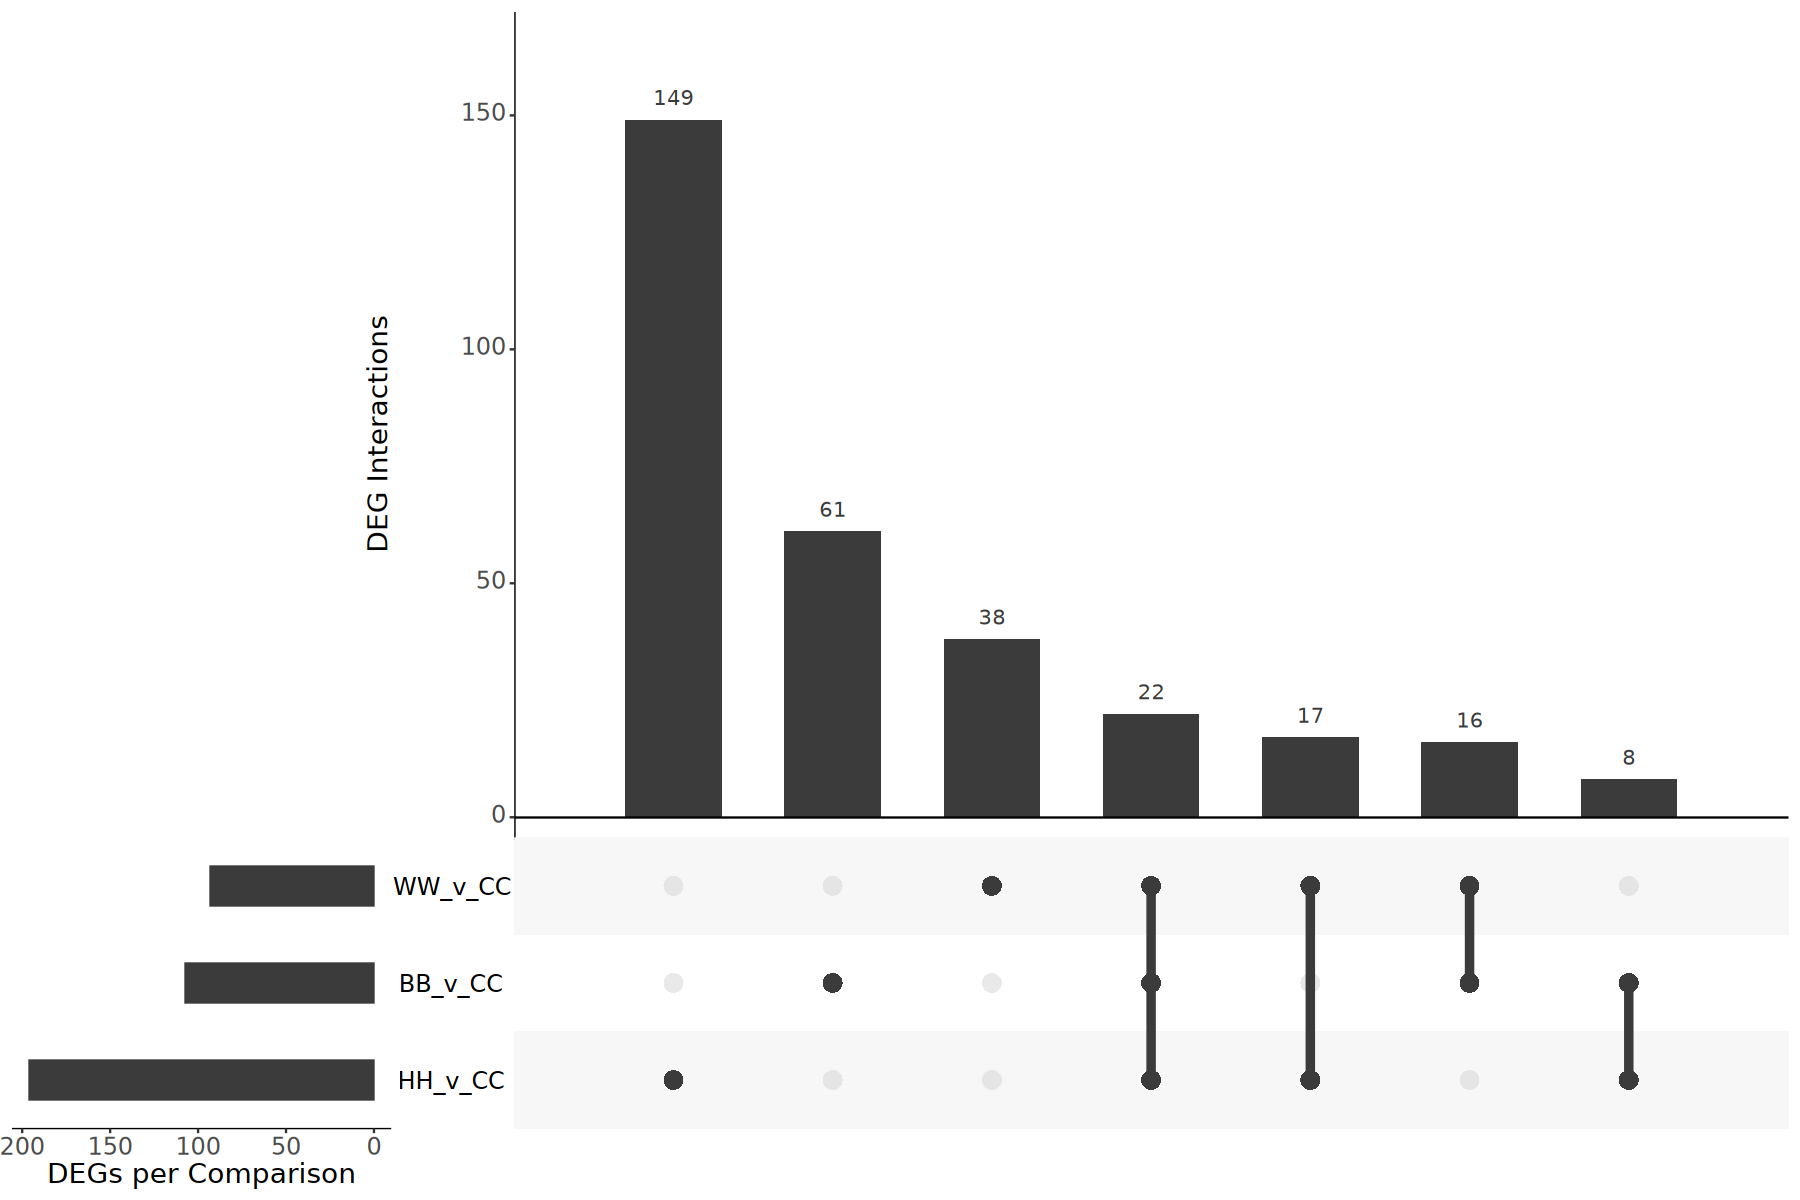

In [30]:
options(repr.plot.width=15, repr.plot.height=10)

comp4.upset <- UpSetR::upset(fromList(comp4), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

comp4.upset

- interesting that HH vs. CC elicits the most DEGs (in past comparisons, hypoxia has had the least amount of DEGs and both has had the most)
- 22 shared between all 3 comparisons - general response to repeated exposure to the same stressor - maybe stress resilience genes??

#### pull 22 shared genes 

In [31]:
# pull out the 22 shared genes across all 3 comparisons
shared_gene2 <- deg_list$ww_cc %>%
  inner_join(deg_list$hh_cc, by = "Gene") %>%
  inner_join(deg_list$bb_cc, by = "Gene") %>%
  pull(Gene) %>%
  unique()

length(shared_gene2)
shared_gene2

[1] 22

[1] "LOC111102028" "LOC111101301" "LOC111127247" "LOC144624450" "LOC144623813"
 [6] "LOC111116266" "LOC144624833" "LOC144624971" "LOC144625005" "LOC144626817"
[11] "LOC111133942" "LOC111136642" "LOC111134504" "LOC111100026" "LOC144619223"
[16] "LOC144619236" "LOC111119065" "LOC111114254" "LOC144621228" "LOC144621324"
[21] "LOC111114643" "LOC144621941"

In [32]:
gff.file[gff.file$gene %in% shared_gene2, ]

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
88655,uncharacterized LOC111102028,LOC111102028,lncRNA
90482,uncharacterized LOC111101301,LOC111101301,protein_coding
172907,uncharacterized LOC111127247,LOC111127247,protein_coding
330103,uncharacterized LOC144624450,LOC144624450,protein_coding
338170,uncharacterized LOC144623813,LOC144623813,protein_coding
393852,uncharacterized LOC111116266,LOC111116266,lncRNA
415518,uncharacterized LOC144624833,LOC144624833,lncRNA
524639,spore cortex-lytic enzyme-like,LOC144624971,protein_coding
543419,lectin BRA-3-like,LOC144625005,protein_coding


so most of the 22 shared DEGs are uncharacterized (sad), but there are 3 identified DEGs:
- LOC144624971: spore cortex-lytic enzyme-like (seen above too)
c- LOC144625005: lectin BRA-3-like
    - sugar-binding protein - binds cell-surface glycoproteins and glyolipids
    - may have defense functions? ([source](https://www.uniprot.org/uniprotkb/P17346/entry))
    - [paper](https://www.frontiersin.org/journals/endocrinology/articles/10.3389/fendo.2022.891714/full) that found BRA-3 downregulated in Sydney Rock Oysters
    - [paper](https://www.tandfonline.com/doi/abs/10.1080/00021369.1985.10866675) about BRA-3 in acorn barnacle
- LOC111119065: microfibril-associated glycoprotein 4-like (MFAP4)
    - calcium-dependent cell adhesion or intracellular interactions in humans ([source](https://www.uniprot.org/uniprotkb/P55083/entry))
    - [fish thesis](https://ir.lib.uth.gr/xmlui/bitstream/handle/11615/87931/33214.pdf?sequence=4) about mfap4 in response to early stress in sea bream -  homeostasis role?

## 4. Upset plots *between* comparison groups

I'm curious if there's overlap in comparisons like CC vs. WC, CC vs. CW, and CC vs. WW - this should tell us strategies oysters use to deal with timing and repeated stressors

### Warming against control oysters

In [33]:
# make list of dfs
warm = list(WW_v_CC = deg_list$ww_cc$Gene,
         WC_v_CC = deg_list$wc_cc$Gene,
         CW_v_CC = deg_list$cw_cc$Gene)

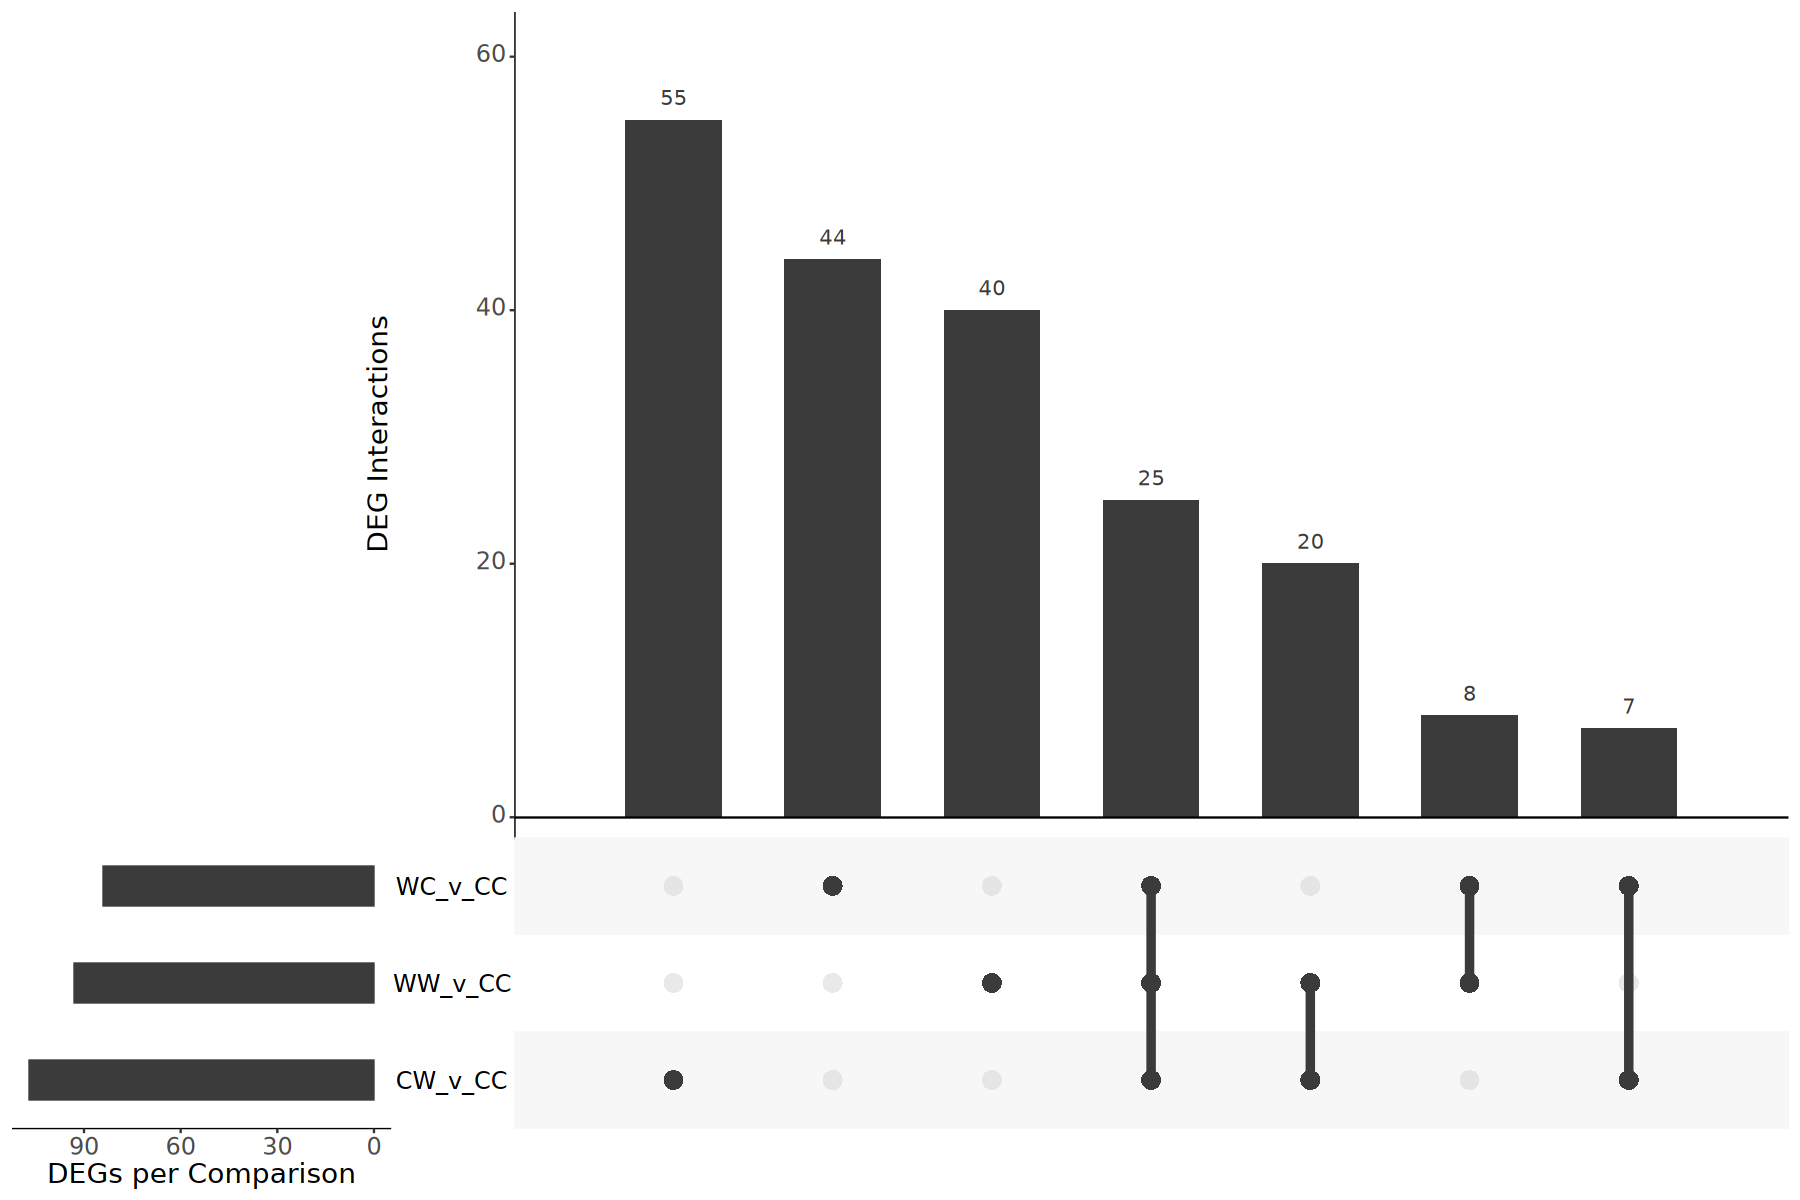

In [34]:
options(repr.plot.width=15, repr.plot.height=10)

warm.upset <- UpSetR::upset(fromList(warm), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

warm.upset

it's interesting that all three comparisons have roughly the same number of DEGs, but the majority are unique to that comparison - I wonder if there's functional redundancy

#### pull 25 shared genes 

In [35]:
# pull out the 25 shared genes across all 3 comparisons
shared_gene4 <- deg_list$wc_cc %>%
  inner_join(deg_list$ww_cc, by = "Gene") %>%
  inner_join(deg_list$cw_cc, by = "Gene") %>%
  pull(Gene) %>%
  unique()

length(shared_gene4)
shared_gene4

[1] 25

[1] "LOC111102028" "LOC111127247" "LOC144624450" "LOC144623813" "LOC144623104"
 [6] "LOC111113307" "LOC111116266" "LOC144624833" "LOC144624971" "LOC144626817"
[11] "LOC111099077" "LOC111136642" "LOC111110618" "LOC111108826" "LOC144618695"
[16] "LOC144619223" "LOC144619016" "LOC111137950" "LOC144619031" "LOC111119065"
[21] "LOC111114254" "LOC111114163" "LOC144621228" "LOC144621324" "LOC144621941"

In [36]:
gff.file[gff.file$gene %in% shared_gene4, ]

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
88655,uncharacterized LOC111102028,LOC111102028,lncRNA
172907,uncharacterized LOC111127247,LOC111127247,protein_coding
330103,uncharacterized LOC144624450,LOC144624450,protein_coding
338170,uncharacterized LOC144623813,LOC144623813,protein_coding
353948,uncharacterized LOC144623104,LOC144623104,protein_coding
377737,IgGFc-binding protein-like,LOC111113307,protein_coding
393852,uncharacterized LOC111116266,LOC111116266,lncRNA
415518,uncharacterized LOC144624833,LOC144624833,lncRNA
524639,spore cortex-lytic enzyme-like,LOC144624971,protein_coding


In [37]:
write.csv(gff.file[gff.file$gene %in% shared_gene4, ], '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deg_interest/warm_sharedAll.csv', row.names = FALSE)

- LOC111113307: lgGFc-binding protein-like
- LOC144624971: SCLE
- LOC144618695: HSP70
- LOC111137950: blastula protease 10-like
    - enables metalloendopeptidase activity and zin ion binding, involved in proteolysis
    - BP10 - involved in sea urchin embrogenesis [Silva et al, 2006](https://www.jbc.org/article/S0021-9258(19)56247-0/fulltext)
- LOC111119065: MFAP-4

### Hypoxia against control oysters

In [38]:
# make list of dfs
hypoxia = list(HH_v_CC = deg_list$hh_cc$Gene,
         HC_v_CC = deg_list$hc_cc$Gene,
         CH_v_CC = deg_list$ch_cc$Gene)

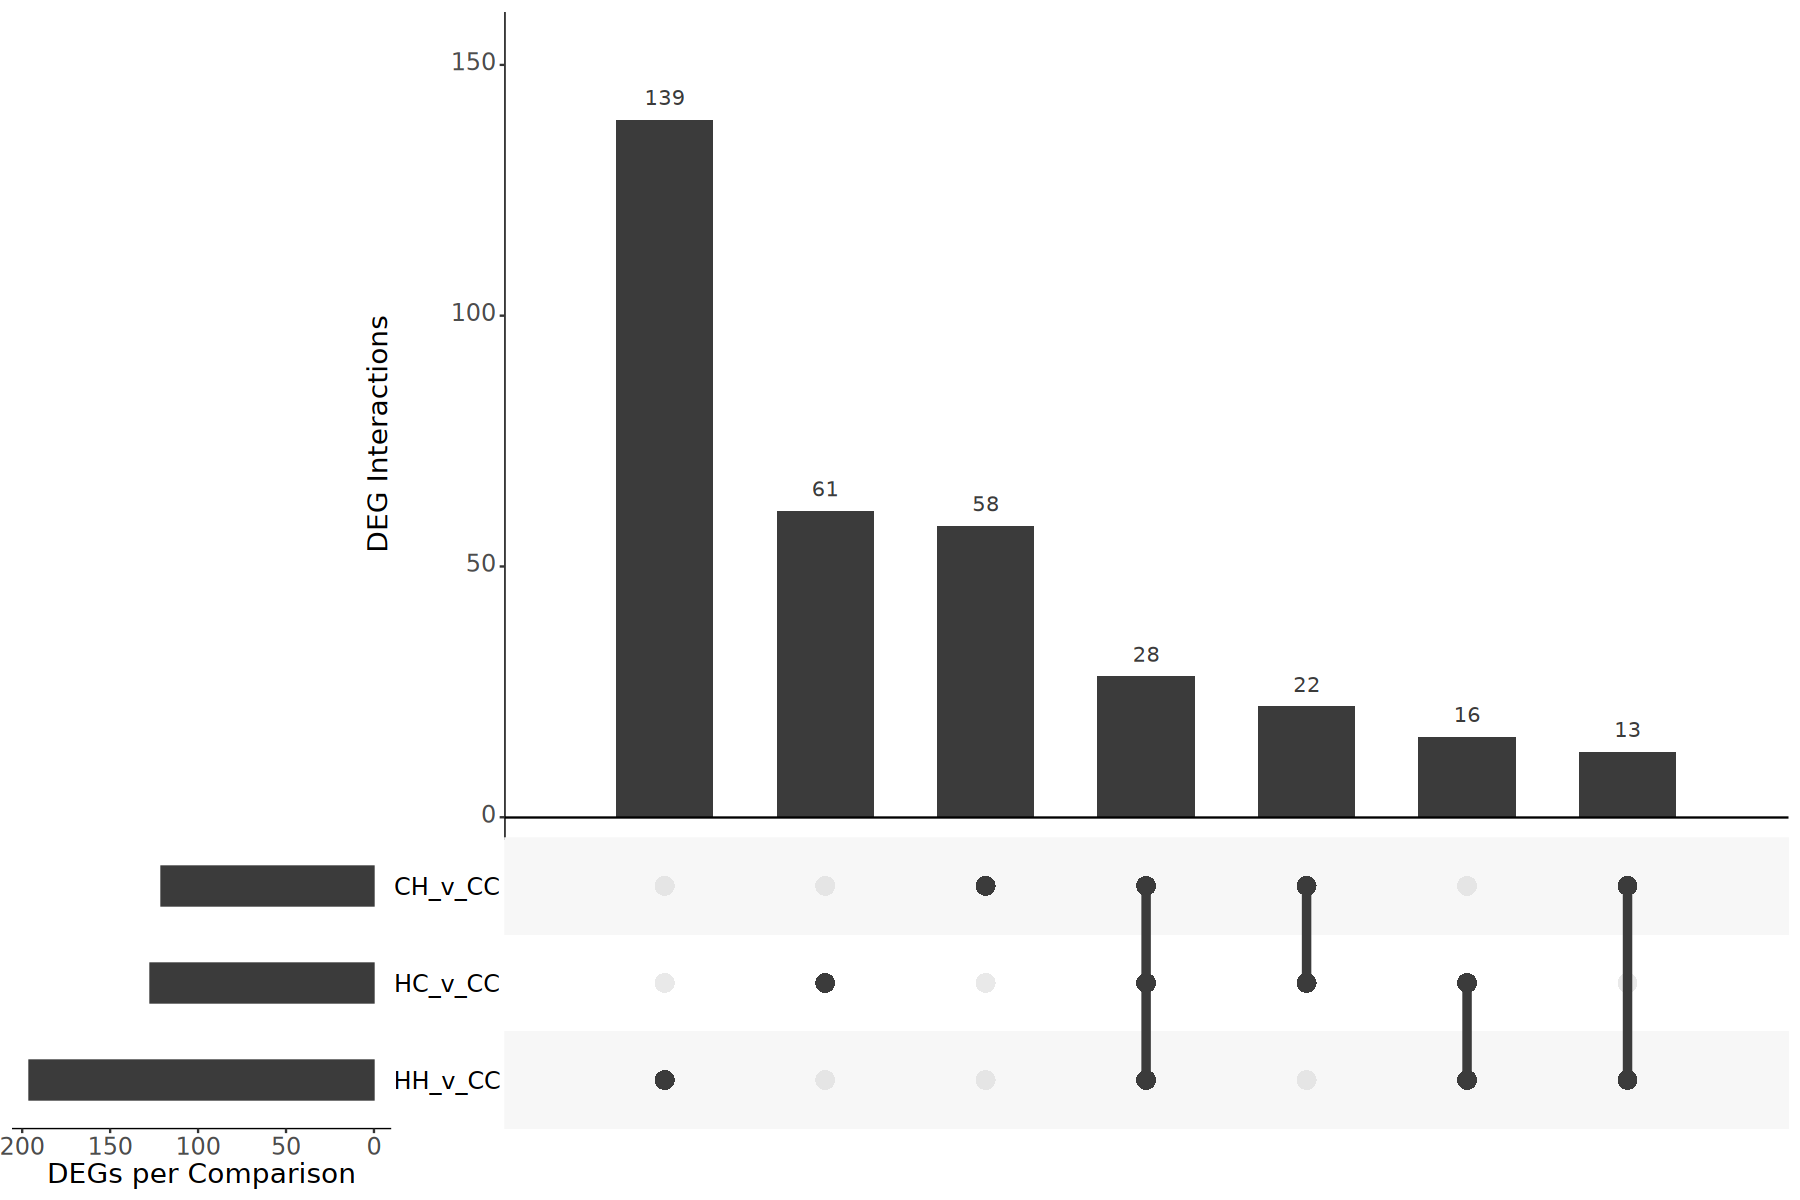

In [39]:
options(repr.plot.width=15, repr.plot.height=10)

hypoxia.upset <- UpSetR::upset(fromList(hypoxia), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

hypoxia.upset

#### pull 28 shared genes

In [40]:
# pull out the 25 shared genes across all 3 comparisons
shared_gene5 <- deg_list$ch_cc %>%
  inner_join(deg_list$hc_cc, by = "Gene") %>%
  inner_join(deg_list$hh_cc, by = "Gene") %>%
  pull(Gene) %>%
  unique()

length(shared_gene5)
shared_gene5

[1] 28

[1] "LOC111102028" "LOC111127247" "LOC144624450" "LOC144623813" "LOC111113693"
 [6] "LOC144624732" "LOC111116266" "LOC111116214" "LOC144624833" "LOC144624971"
[11] "LOC144625005" "LOC111116296" "LOC111136642" "LOC111132872" "LOC111137992"
[16] "LOC111134504" "LOC111100026" "LOC111108826" "LOC111138244" "LOC111128708"
[21] "LOC111130777" "LOC111130993" "LOC111122019" "LOC111114254" "LOC144621228"
[26] "LOC144621324" "LOC111114643" "LOC144621941"

In [41]:
gff.file[gff.file$gene %in% shared_gene4, ]

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
88655,uncharacterized LOC111102028,LOC111102028,lncRNA
172907,uncharacterized LOC111127247,LOC111127247,protein_coding
330103,uncharacterized LOC144624450,LOC144624450,protein_coding
338170,uncharacterized LOC144623813,LOC144623813,protein_coding
353948,uncharacterized LOC144623104,LOC144623104,protein_coding
377737,IgGFc-binding protein-like,LOC111113307,protein_coding
393852,uncharacterized LOC111116266,LOC111116266,lncRNA
415518,uncharacterized LOC144624833,LOC144624833,lncRNA
524639,spore cortex-lytic enzyme-like,LOC144624971,protein_coding


yea all the same DEGs as above

#### Both warming and hypoxia against control oysters

In [42]:
# make list of dfs
both = list(BB_v_CC = deg_list$bb_cc$Gene,
         BC_v_CC = deg_list$bc_cc$Gene,
         CB_v_CC = deg_list$cb_cc$Gene)

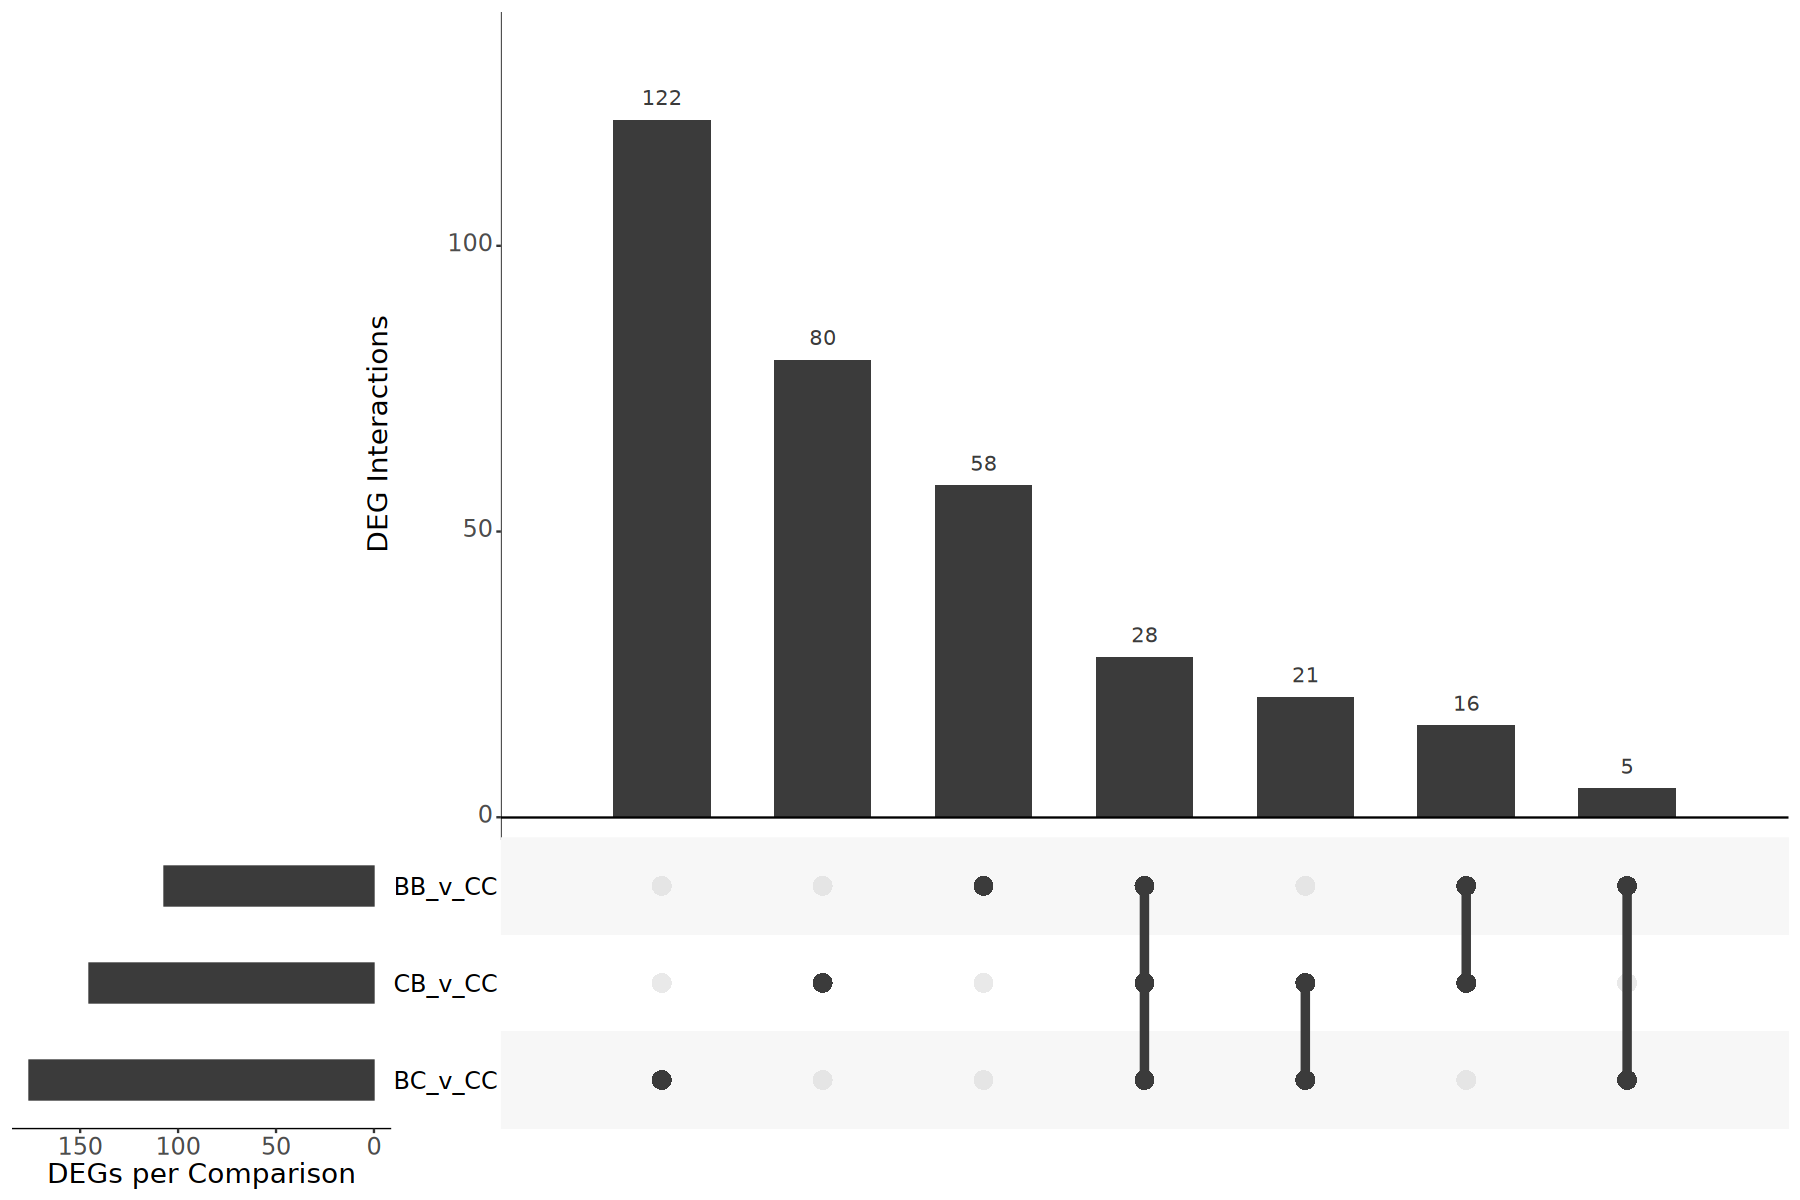

In [43]:
options(repr.plot.width=15, repr.plot.height=10)

both.upset <- UpSetR::upset(fromList(both), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

both.upset

## stress sets
meaning, fully factorial set of pairwise comparisons within a single stressor type and control

In [44]:
# make list of dfs
warming = list(CW_v_CC = deg_list$cw_cc$Gene,
         WC_v_CC = deg_list$wc_cc$Gene,
         WW_v_CC = deg_list$ww_cc$Gene,
              CW_v_WC = deg_list$cw_wc$Gene,
              WW_v_CW = deg_list$ww_cw$Gene,
              WC_v_WW = deg_list$wc_ww$Gene)

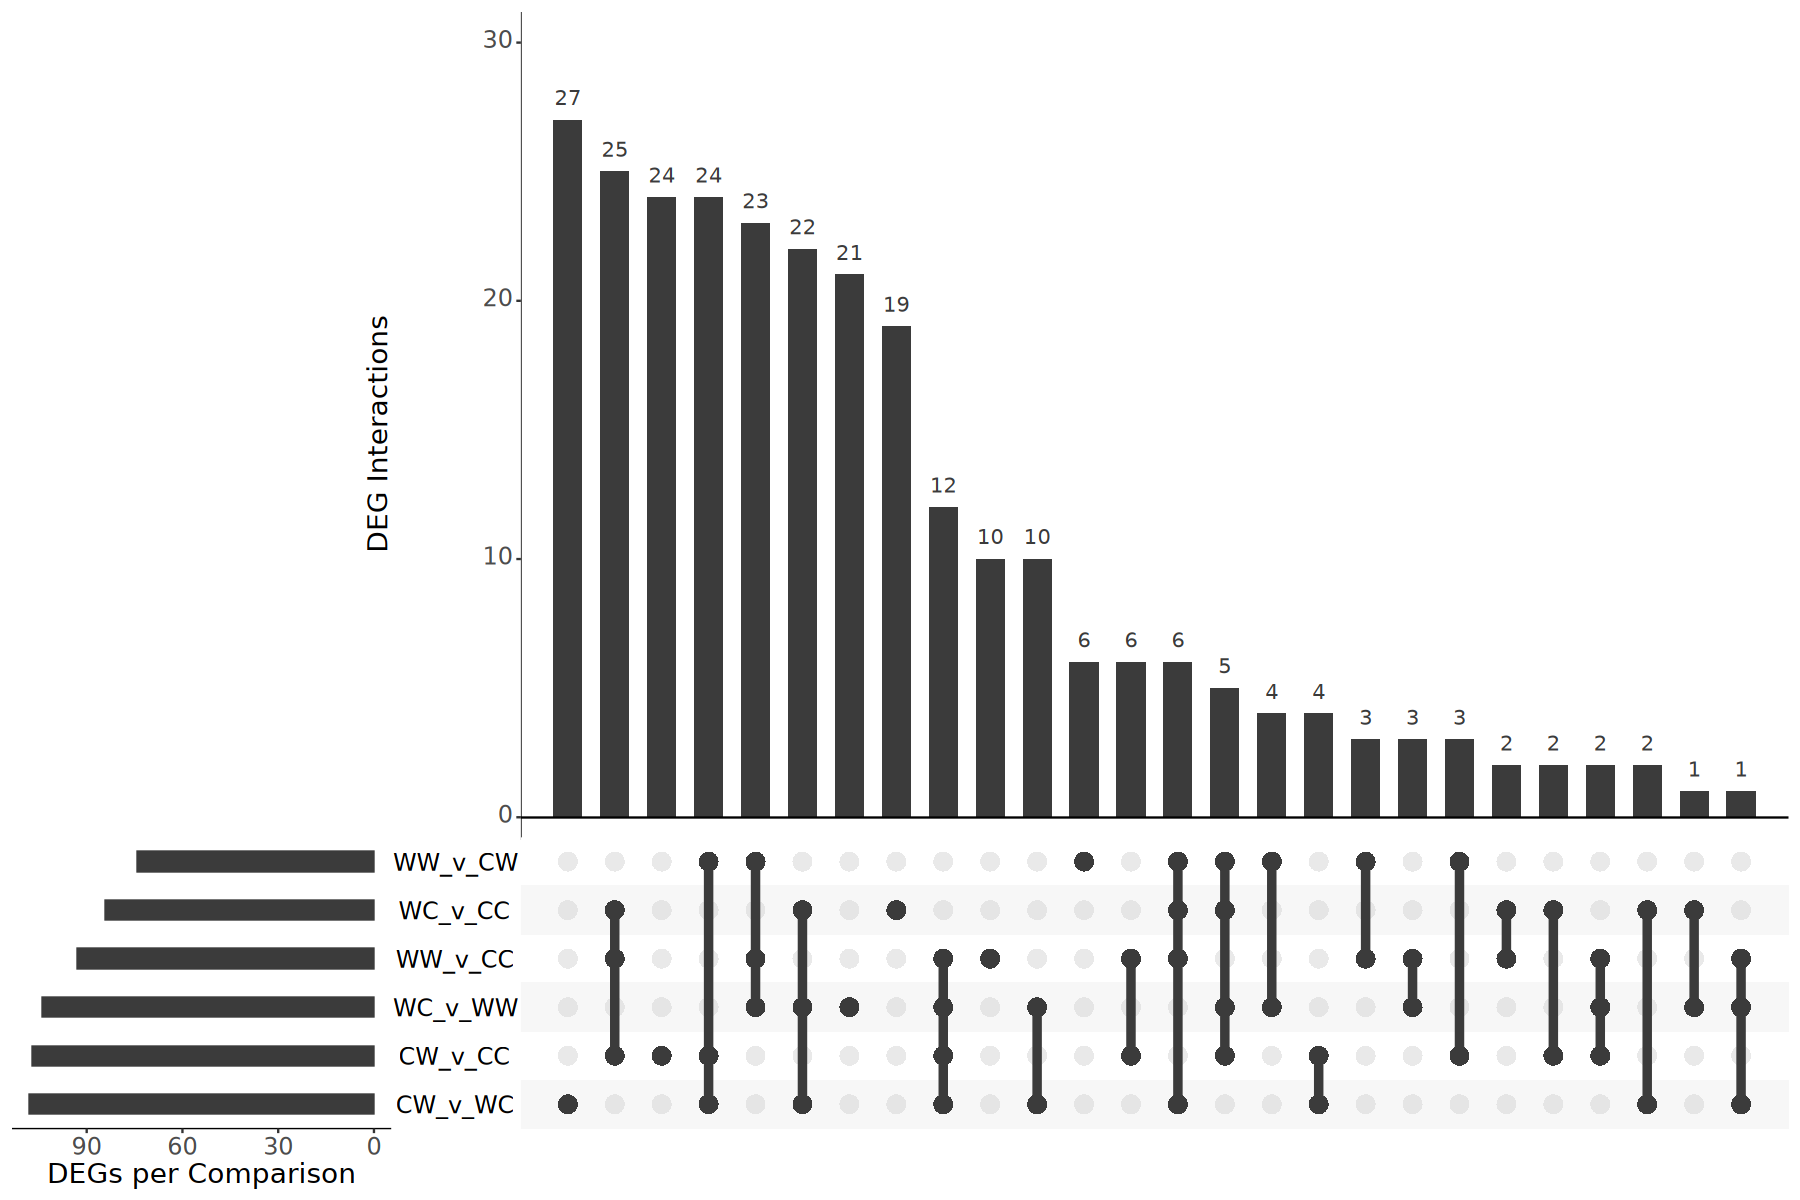

In [45]:
options(repr.plot.width=15, repr.plot.height=10)

warming.upset <- UpSetR::upset(fromList(warming), nsets = 6,, order.by='freq', point.size = 5, line.size = 2,
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

warming.upset

### comparison 1, 2, and 4 together

In [46]:
# make list of dfs
comp1_2_4 = list(WC_v_CC = deg_list$wc_cc$Gene,
               HC_v_CC = deg_list$hc_cc$Gene,
               BC_v_CC = deg_list$bc_cc$Gene,
               CW_v_CC = deg_list$cw_cc$Gene,
               CH_v_CC = deg_list$ch_cc$Gene,
               CB_v_CC = deg_list$cb_cc$Gene,
               WW_v_CC = deg_list$ww_cc$Gene,
               HH_v_CC = deg_list$hh_cc$Gene,
               BB_v_CC = deg_list$bb_cc$Gene
              )

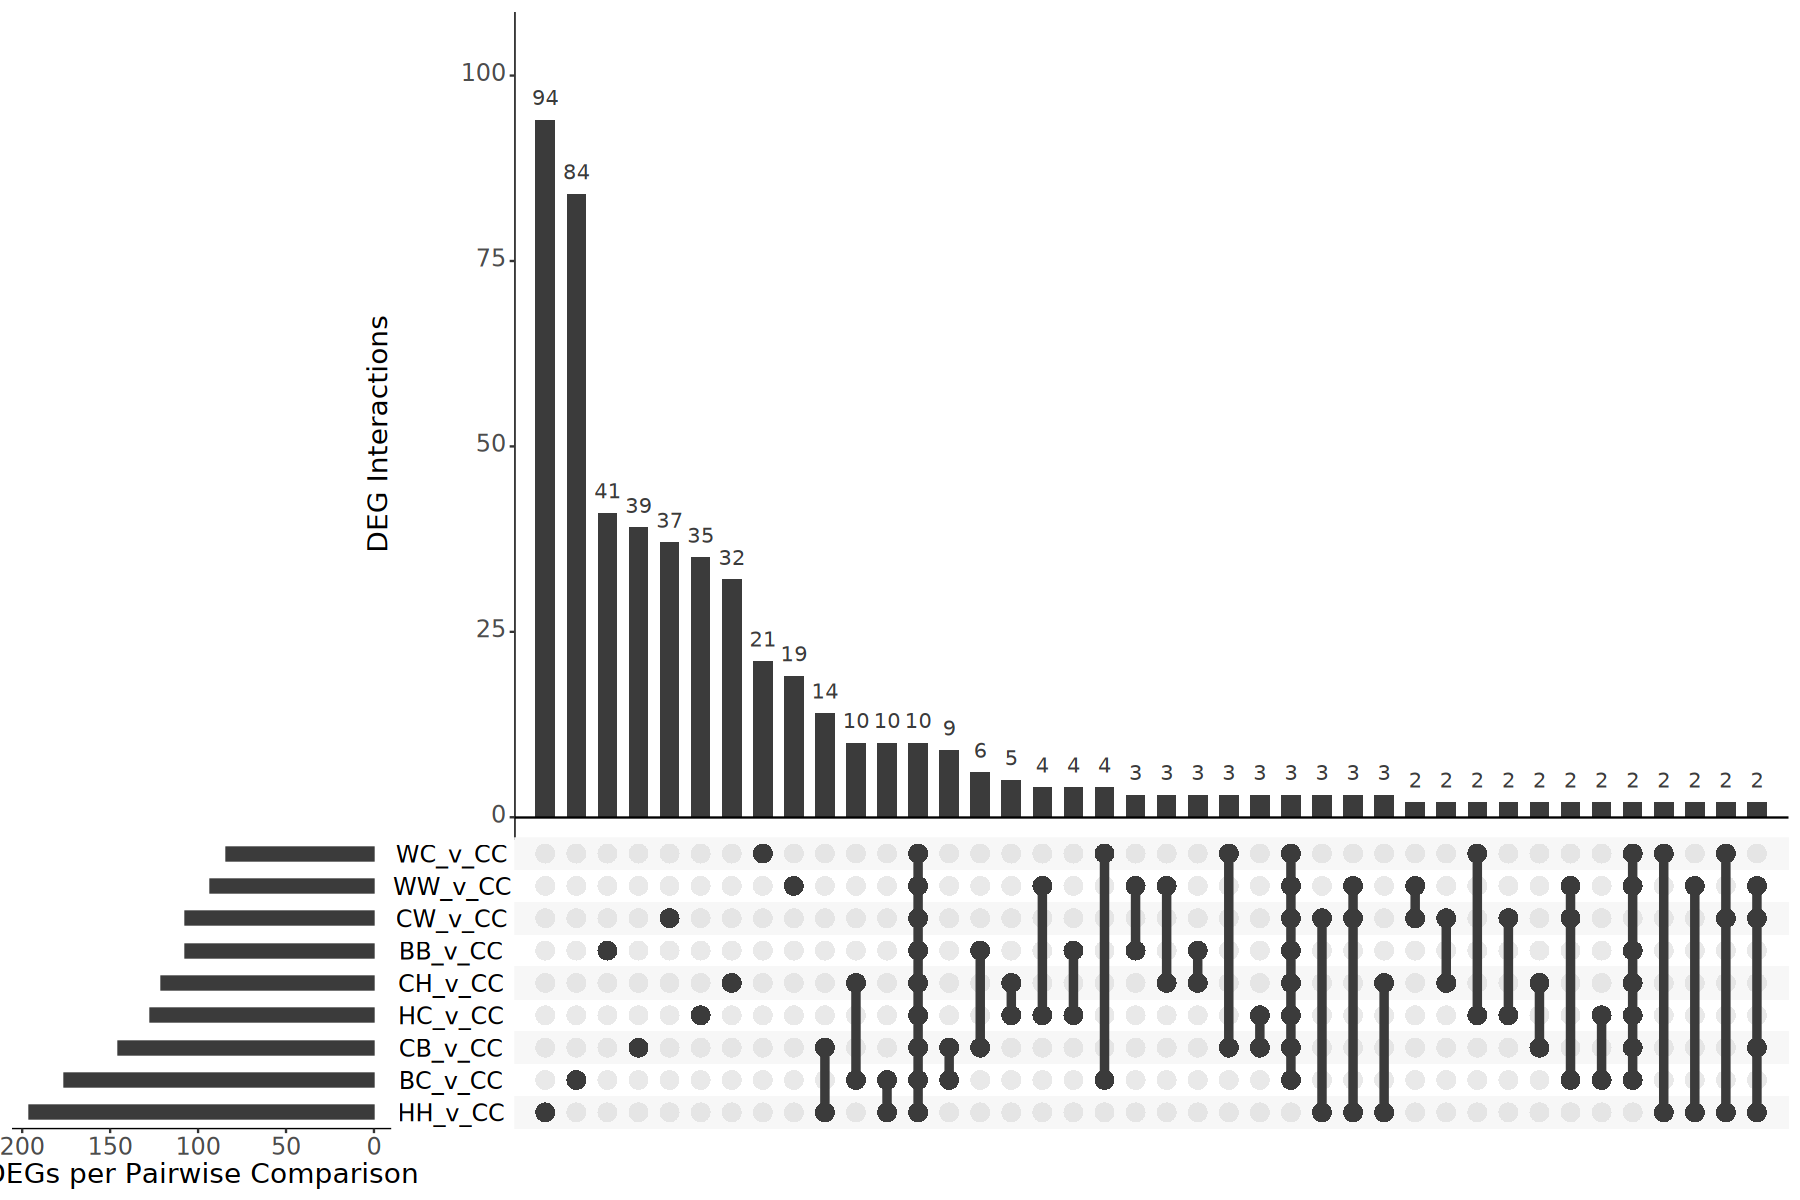

In [47]:
options(repr.plot.width=15, repr.plot.height=10)

comp1_2_4.upset <- UpSetR::upset(fromList(comp1_2_4), 
                         nsets = 9,
                         order.by='freq', 
                         point.size = 5, 
                         line.size = 2, 
                         keep.order=TRUE,
                         mainbar.y.label = "DEG Interactions", 
                         sets.x.label = "DEGs per Pairwise Comparison", 
                         text.scale = c(2, 2, 2, 2, 2, 2))

comp1_2_4.upset

there's 10 DEGs that are shared between all of these comparisons (vs. control) - so probably part of the ***general stress response*** (would be interesting to see if they're regulated in the same way in all the comparisons)

#### pull 10 shared genes

In [50]:
# pull out the 10 shared genes across all 9 comparisons
shared_gene10 <- deg_list$wc_cc %>%
  inner_join(deg_list$ww_cc, by = "Gene") %>%
  inner_join(deg_list$cw_cc, by = "Gene") %>%
inner_join(deg_list$bb_cc, by = "Gene") %>%
inner_join(deg_list$ch_cc, by = "Gene") %>%
inner_join(deg_list$hc_cc, by = "Gene") %>%
inner_join(deg_list$cb_cc, by = "Gene") %>%
inner_join(deg_list$bc_cc, by = "Gene") %>%
inner_join(deg_list$hh_cc, by = "Gene") %>%
  pull(Gene) %>%
  unique()

length(shared_gene10)
shared_gene10

[1] 10

[1] "LOC111102028" "LOC111127247" "LOC144624450" "LOC111116266" "LOC144624833"
 [6] "LOC144624971" "LOC111136642" "LOC144621228" "LOC144621324" "LOC144621941"

In [49]:
gff.file[gff.file$gene %in% shared_gene6, ]

,description,gene,gene_biotype
,<chr>,<chr>,<chr>
88655,uncharacterized LOC111102028,LOC111102028,lncRNA
172907,uncharacterized LOC111127247,LOC111127247,protein_coding
330103,uncharacterized LOC144624450,LOC144624450,protein_coding
393852,uncharacterized LOC111116266,LOC111116266,lncRNA
415518,uncharacterized LOC144624833,LOC144624833,lncRNA
524639,spore cortex-lytic enzyme-like,LOC144624971,protein_coding
704434,uncharacterized LOC111136642,LOC111136642,protein_coding
1330437,uncharacterized LOC144621228,LOC144621228,protein_coding
1331401,uncharacterized LOC144621324,LOC144621324,protein_coding


all uncharacterized except for SCLE

pull out relative expression of these genes? are they up- or down-regulated in the same ways?

In [64]:
shared_expr <- deg_list$ww_cc %>%
filter(Gene %in% shared_gene10) %>%
select(c(1, 9:102)) %>%
pivot_longer(
    cols = c(2:95),
    names_to = 'Sample',
    values_to = 'vst_expr')

head(shared_expr)

Gene,Sample,vst_expr
<chr>,<chr>,<dbl>
LOC111102028,B1_B1_O01,0.000000
LOC111102028,B1_W5_O50,3.029628
LOC111102028,B2_B5_O51,5.739099
LOC111102028,B2_C4_O40,0.000000
LOC111102028,B3_B4_O41,27.922986
LOC111102028,B3_C3_O30,0.000000


need to add meta data to plot

In [57]:
metaData <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')
head(metaData)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


In [66]:
shared_gene.merge <- merge(metaData, shared_expr, by = 'Sample')
head(shared_gene.merge)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,Gene,vst_expr
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC111102028,0.0000000
2,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC111127247,0.9503776
3,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144624971,1.9007552
4,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144621941,0.0000000
5,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144621228,0.0000000
6,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144624833,0.0000000


in the comparisons I used to identify these genes, I didn't use all of the samples - only those in the "stress sets" - so I need to filter my samples for those

In [77]:
shared_gene.filter <- shared_gene.merge %>%
mutate(treatment = case_when(
    Phase1_treatment == 'control' & Phase2_treatment == 'control' ~ 'CC',
    Phase1_treatment == 'control' & Phase2_treatment == 'warm' ~ 'CW',
    Phase1_treatment == 'control' & Phase2_treatment == 'hypoxic' ~ 'CH',
    Phase1_treatment == 'control' & Phase2_treatment == 'both' ~ 'CB',
    Phase1_treatment =='warm' & Phase2_treatment == 'control' ~ 'WC',
    Phase1_treatment == 'hypoxic' & Phase2_treatment == 'control' ~ 'HC',
    Phase1_treatment == 'both' & Phase2_treatment == 'control' ~ 'BC',
    Phase1_treatment == 'both' & Phase2_treatment == 'both' ~ 'BB',
    Phase1_treatment == 'warm' & Phase2_treatment == 'warm' ~ 'WW',
    Phase1_treatment == 'hypoxic' & Phase2_treatment == 'hypoxic' ~ 'HH'
    )) %>%
na.omit() # remove the rows that have NA in their treatment, which means I didn't assign a treatment

head(shared_gene.filter)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,Gene,vst_expr,treatment
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<chr>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC111102028,0.0000000,BB
2,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC111127247,0.9503776,BB
3,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144624971,1.9007552,BB
4,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144621941,0.0000000,BB
5,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144621228,0.0000000,BB
6,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,LOC144624833,0.0000000,BB


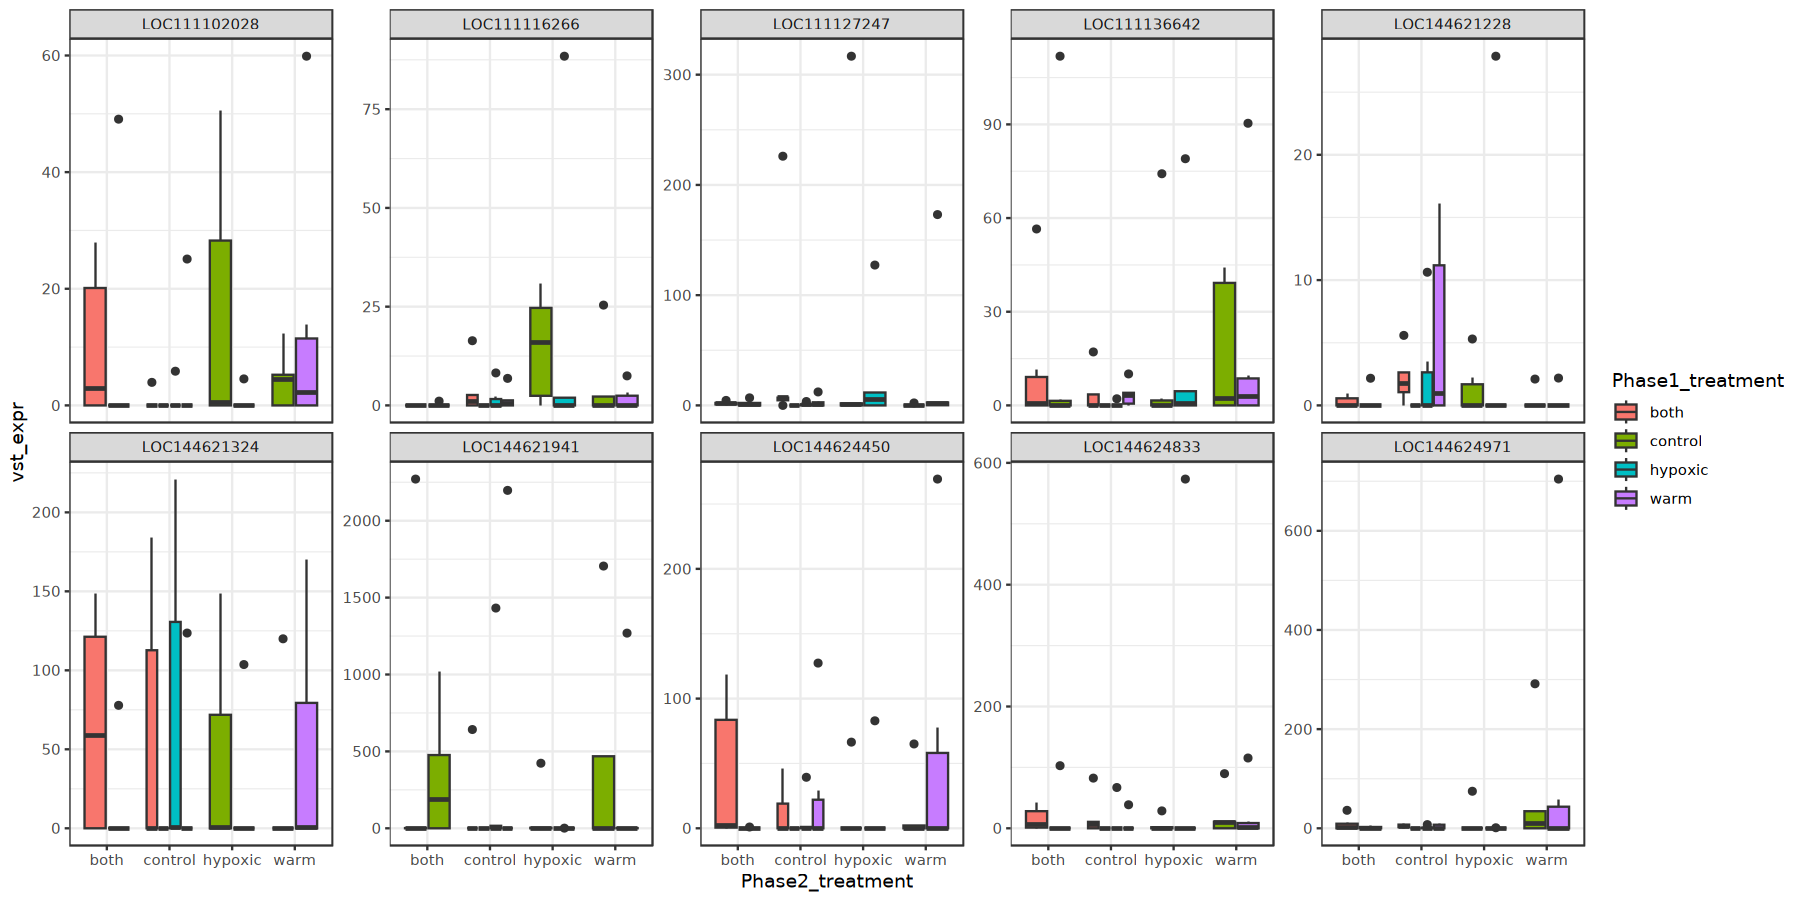

In [82]:
options(repr.plot.height = 7.5, repr.plot.width = 15)

ggplot(shared_gene.filter, aes(x = Phase2_treatment, y = vst_expr, fill = Phase1_treatment)) +
geom_boxplot() +
facet_wrap(~Gene, scales = 'free_y', nrow = 2, ncol = 5) +
theme_bw()

there's a lot of points, which indicates outliers - so it's possible that these DEGs are being driven by one sample 

all of these genes are uncharacterized except for SCLE which is LOC 144624971 in the bottom right

how many of these genes have samples with 0 expression?

In [90]:
shared_gene.filter %>%
group_by(Gene, treatment) %>%
  summarise(across(vst_expr, 
                   list(max = max, mean = mean, min = min), 
                   .names = "{.col}_{.fn}"))

`summarise()` has grouped output by 'Gene'. You can override using the
`.groups` argument.


Gene,treatment,vst_expr_max,vst_expr_mean,vst_expr_min
<chr>,<chr>,<dbl>,<dbl>,<dbl>
LOC111102028,BB,27.922986,9.7654918,0
LOC111102028,BC,3.951160,0.7902319,0
LOC111102028,CB,49.080323,8.1800538,0
LOC111102028,CC,0.000000,0.0000000,0
LOC111102028,CH,50.605645,14.8373736,0
LOC111102028,CW,12.371912,4.4224719,0
LOC111102028,HC,5.864118,0.9773530,0
LOC111102028,HH,4.546100,0.9092200,0
LOC111102028,WC,25.098604,4.1831006,0


okay so almost all of them have some at least one sample with 0 expression